# Carregar dados para a memória

In [1]:
import pandas as pd
from pathlib import Path

# Path to the directory

# df = pd.DataFrame()

# for file in files:
#     print(file.name)
#     aux_df = pd.read_csv(f"{directory_path}/{file.name}", sep=';')
#     df = pd.concat([df, aux_df])

df = pd.read_parquet("0.raw.parquet")
df = pd.read_csv(f"HIST_PAINEL_COVIDBR_2020_Parte1_18abr2025.csv", sep=';')
df = df.reset_index()

len(df)

714481

## Exemplo de outlier
No dia 2020-06-04 no Rio de Janeiro os casos foram registrados normalmente.

In [2]:
df.loc[418132]

index                              418132
regiao                            Sudeste
estado                                 RJ
municipio                  Rio de Janeiro
coduf                                  33
codmun                           330455.0
codRegiaoSaude                    33005.0
nomeRegiaoSaude           METROPOLITANA I
data                           2020-06-04
semanaEpi                              23
populacaoTCU2019                6718903.0
casosAcumulado                      33695
casosNovos                            744
obitosAcumulado                      4231
obitosNovos                           176
Recuperadosnovos                      NaN
emAcompanhamentoNovos                 NaN
interior/metropolitana                1.0
Name: 418132, dtype: object

Porém no dia 2020-06-05 tivemos um registro de 1.372.984 casos novos.

In [3]:
df.loc[418133]

index                              418133
regiao                            Sudeste
estado                                 RJ
municipio                  Rio de Janeiro
coduf                                  33
codmun                           330455.0
codRegiaoSaude                    33005.0
nomeRegiaoSaude           METROPOLITANA I
data                           2020-06-05
semanaEpi                              23
populacaoTCU2019                6718903.0
casosAcumulado                    1408687
casosNovos                        1374992
obitosAcumulado                     38643
obitosNovos                         34412
Recuperadosnovos                      NaN
emAcompanhamentoNovos                 NaN
interior/metropolitana                1.0
Name: 418133, dtype: object

E foi removido no dia 2020-06-06

In [4]:
df.loc[418134]

index                              418134
regiao                            Sudeste
estado                                 RJ
municipio                  Rio de Janeiro
coduf                                  33
codmun                           330455.0
codRegiaoSaude                    33005.0
nomeRegiaoSaude           METROPOLITANA I
data                           2020-06-06
semanaEpi                              23
populacaoTCU2019                6718903.0
casosAcumulado                      35703
casosNovos                       -1372984
obitosAcumulado                      4401
obitosNovos                        -34242
Recuperadosnovos                      NaN
emAcompanhamentoNovos                 NaN
interior/metropolitana                1.0
Name: 418134, dtype: object

# Remover dados faltantes

Removemos registros com municipio faltante pois ele pode prejudicar a contagem total de casos.

In [5]:
not_na_df = df[df['municipio'].notna()]
len(df), len(not_na_df), len(df) - len(not_na_df)

(714481, 707390, 7091)

# Remover outliers

Os outliers nos _casosNovos_ impactam os _casosAcumulado_, então removeremos os outliers dos _casosNovos_ e recalcularemos os _casosAcumulado_.

## Tratando outliers

In [6]:
box_plot_df = pd.melt(df, id_vars=['index'], value_vars=['casosNovos', 'obitosNovos'])

In [7]:
df.columns

Index(['index', 'regiao', 'estado', 'municipio', 'coduf', 'codmun',
       'codRegiaoSaude', 'nomeRegiaoSaude', 'data', 'semanaEpi',
       'populacaoTCU2019', 'casosAcumulado', 'casosNovos', 'obitosAcumulado',
       'obitosNovos', 'Recuperadosnovos', 'emAcompanhamentoNovos',
       'interior/metropolitana'],
      dtype='object')

<Axes: xlabel='value', ylabel='variable'>

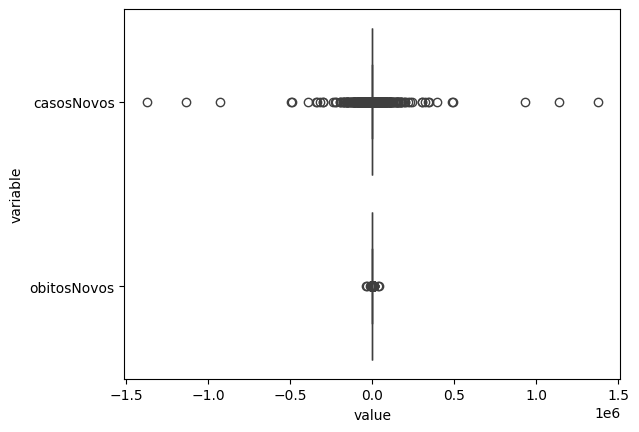

In [8]:
import seaborn as sns

sns.boxplot(data=box_plot_df, x="value", y="variable")

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df["z_score"] = scaler.fit_transform(df[['casosNovos']])

df["z_score"].describe()

count    7.144810e+05
mean     1.586208e-18
std      1.000001e+00
min     -3.167689e+02
25%     -2.579237e-03
50%     -2.579237e-03
75%     -2.348523e-03
max      3.172270e+02
Name: z_score, dtype: float64

Com isso definimos que um limite ideal para corte será de 3.

In [10]:
LIMITE_COMUM = 1

df_zscore = df[abs(df["z_score"]) < LIMITE_COMUM]

print("Antes da remoção de outliers: ", len(df), "| Depois: ", len(df_zscore))
print("Diferença: ", len(df) - len(df_zscore))

Antes da remoção de outliers:  714481 | Depois:  711571
Diferença:  2910


<Axes: title={'center': 'Depois da remoção de outliers'}, xlabel='casosNovos'>

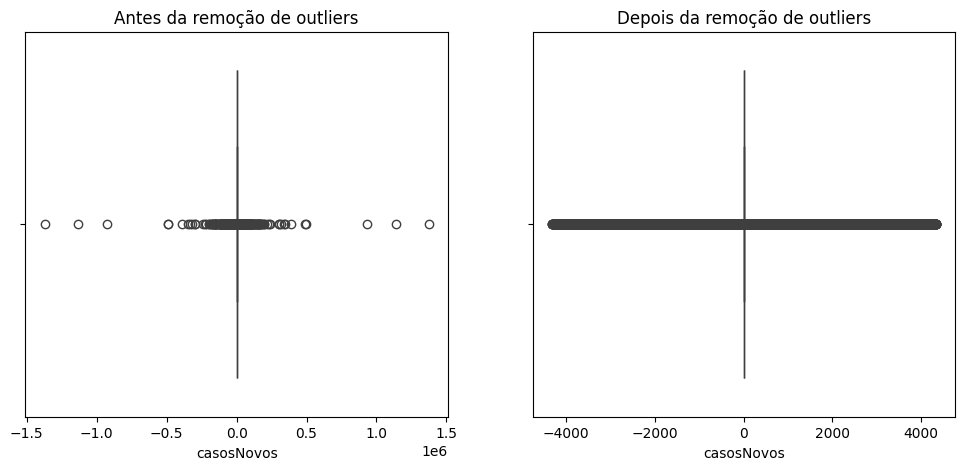

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.title("Antes da remoção de outliers")
sns.boxplot(data=df, x="casosNovos")

plt.subplot(1,2,2)
plt.title("Depois da remoção de outliers")
sns.boxplot(data=df_zscore, x="casosNovos")

### Linha do tempo

In [12]:
import seaborn as sns
import numpy as np
import matplotlib.dates
import matplotlib.pyplot as plt 
import locale

locale.setlocale(locale.LC_ALL, 'pt_BR.UTF-8')
plt.rcParams['axes.formatter.use_locale'] = True

def plot_comparacao_outliers_1(df1, label1=""):
    plt.figure(figsize=(20,5))
    df1['data'] = pd.to_datetime(df1['data'])
    plt.title(label1)
    sns.lineplot(data=df1, y="casosNovos", x='data')
    
    # Convert dates to matplotlib dates for proper tick placement
    dates = pd.to_datetime(df1['data'])
    mpl_dates = dates.map(matplotlib.dates.date2num)
    
    # Set major ticks every 3 months
    plt.gca().xaxis.set_major_locator(matplotlib.dates.MonthLocator(interval=1))
    
    # Format the date labels
    plt.gca().xaxis.set_major_formatter(matplotlib.dates.DateFormatter('%B %Y'))
    
    # plt.xticks(rotation=90)
    plt.xlabel("")
    plt.ylabel("Casos novos", {'size': 14})

    plt.tick_params(axis='both', labelsize=14)


In [13]:
municipios = ["Rio de Janeiro", "Ouro Branco", "São João del Rei", "Conselheiro Lafaiete"]
plot_df = df[(df['municipio'].isin(municipios)) & ((df['estado'] == 'MG') | (df['estado'] == 'RJ'))]

dados = plot_df[(plot_df['data'] > '2020-05-30') & (plot_df['data'] < '2020-06-15')][['data', 'casosNovos', 'municipio']]

dados.pivot_table(index=['data'], columns=['municipio'], values=['casosNovos'])

casosNovos                                            
municipio  Conselheiro Lafaiete Ouro Branco Rio de Janeiro São João del Rei
data                                                                       
2020-05-31                  0.0         1.0          676.0              0.0
2020-06-01                  1.0         0.0          857.0              2.0
2020-06-02                  0.0         0.0         1190.0              3.0
2020-06-03                  6.0         0.0         1747.0              2.0
2020-06-04                  3.0         0.0          744.0              5.0
2020-06-05              27232.0      9758.0      1374992.0          21453.0
2020-06-06             -27229.0     -9752.0     -1372984.0         -21449.0
2020-06-07                  1.0         0.0          412.0              8.0
2020-06-08                  3.0         0.0          778.0              1.0
2020-06-09                  0.0         2.0         1010.0              1.0
2020-06-10                  3.0         2.0         1057.0              8.0
2020-06-11                  0.0         1.0         1057.0              5.0
2020-06-12                  4.0         0.0          487.0             11.0
2020-06-13                  3.0         1.0          907.0              6.0
2020-06-14                  3.0         1.0          357.0              5.0

C:\Users\AlterUser\AppData\Local\Temp\ipykernel_14608\2343169056.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plot_df_sem_outliers = df_zscore[(df_zscore['municipio'] == 'Ouro Branco') & (df['estado'] == 'MG')]
C:\Users\AlterUser\AppData\Local\Temp\ipykernel_14608\3478348279.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['data'] = pd.to_datetime(df1['data'])


,index,regiao,estado,municipio,coduf,codmun,codRegiaoSaude,nomeRegiaoSaude,data,semanaEpi,populacaoTCU2019,casosAcumulado,casosNovos,obitosAcumulado,obitosNovos,Recuperadosnovos,emAcompanhamentoNovos,interior/metropolitana,z_score
359172,359172,Sudeste,MG,Ouro Branco,31,314590.0,31078.0,CONGONHAS,2020-05-03,19,39500.0,0,-1,0,0,NaN,NaN,0.0,-0.00281
359220,359220,Sudeste,MG,Ouro Branco,31,314590.0,31078.0,CONGONHAS,2020-06-20,25,39500.0,36,-1,0,0,NaN,NaN,0.0,-0.00281


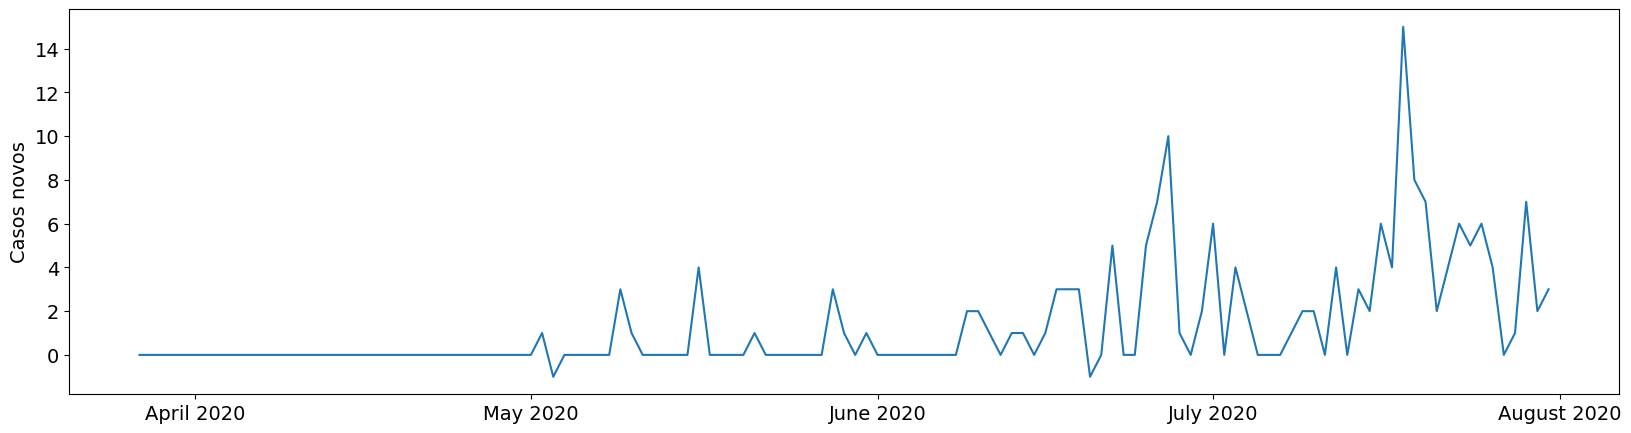

In [23]:
plot_df_sem_outliers = df_zscore[(df_zscore['municipio'] == 'Ouro Branco') & (df['estado'] == 'MG')]
plot_comparacao_outliers_1(plot_df_sem_outliers)

plot_df_sem_outliers[plot_df_sem_outliers['casosNovos'] < 0]

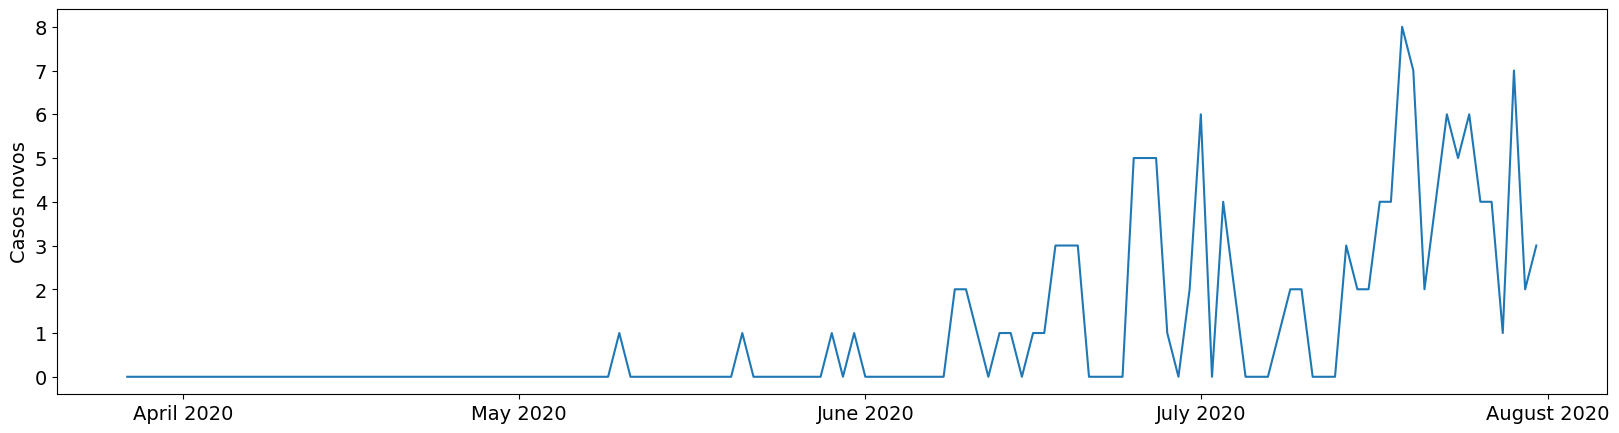

In [53]:
def _suavizar(df, window_size=7, threshold=2):
    """
    Smooth data by replacing outliers with previous day's casosNovos.
    Df must be indexed.
    
    Parameters:
    - df: pandas DataFrame with columns 'date' and 'casosNovos'
    - window_size: number of days to consider in rolling window
    - threshold: number of standard deviations to use for outlier detection
    
    Returns:
    - DataFrame with smoothed values
    """
    # Make a copy to avoid modifying original data
    df_smoothed = df.copy()
    
    # Calculate rolling statistics
    rolling_mean = df['casosNovos'].rolling(window=window_size, center=False, closed='left').mean()
    rolling_std = df['casosNovos'].rolling(window=window_size, center=False, closed='left').std()

    # # Identify outliers (values outside mean ± threshold*std)
    lower_bound = rolling_mean - threshold * rolling_std
    upper_bound = rolling_mean + threshold * rolling_std
    
    is_outlier = (df['casosNovos'] < lower_bound) | (df['casosNovos'] > upper_bound)

    df_smoothed['rolling_mean'] = rolling_mean
    df_smoothed['rolling_std'] = rolling_std
    df_smoothed['lower_bound'] = lower_bound
    df_smoothed['upper_bound'] = upper_bound
    df_smoothed['is_outlier'] = is_outlier
    
    for i in range(1, len(df_smoothed)):
      if is_outlier[i]:
        df_smoothed.at[i, 'casosNovos'] = df_smoothed.at[i-1, 'casosNovos']
    
    return df_smoothed

def _suavizar(df, window_size=7, threshold=2):
    """
    Smooth data by replacing outliers with previous day's casosNovos.
    Df must be indexed.
    
    Parameters:
    - df: pandas DataFrame with columns 'date' and 'casosNovos'
    - window_size: number of days to consider in rolling window
    - threshold: number of standard deviations to use for outlier detection
    
    Returns:
    - DataFrame with smoothed values
    """
    # Make a copy to avoid modifying original data
    df_smoothed = df.copy()
    
    # Calculate rolling statistics
    rolling_mean = df['casosNovos'].rolling(window=window_size, center=False, closed='left').mean()
    rolling_std = df['casosNovos'].rolling(window=window_size, center=False, closed='left').std()

    # # Identify outliers (values outside mean ± threshold*std)
    lower_bound = rolling_mean - threshold * rolling_std
    upper_bound = rolling_mean + threshold * rolling_std
    
    is_outlier = (df['casosNovos'] < lower_bound) | (df['casosNovos'] > upper_bound)

    df_smoothed['rolling_mean'] = rolling_mean
    df_smoothed['rolling_std'] = rolling_std
    df_smoothed['lower_bound'] = lower_bound
    df_smoothed['upper_bound'] = upper_bound
    df_smoothed['is_outlier'] = is_outlier
    
    for i in range(1, len(df_smoothed)):
      if is_outlier[i]:
        df_smoothed.at[i, 'casosNovos'] = df_smoothed.at[i-1, 'casosNovos']
    
    return df_smoothed

city_df = df[(df['municipio'] == 'Ouro Branco') & (df['estado'] == 'MG')]
city_df = city_df.reset_index()

smoothed_df = _suavizar(city_df, window_size=7)
plot_comparacao_outliers_1(smoothed_df)

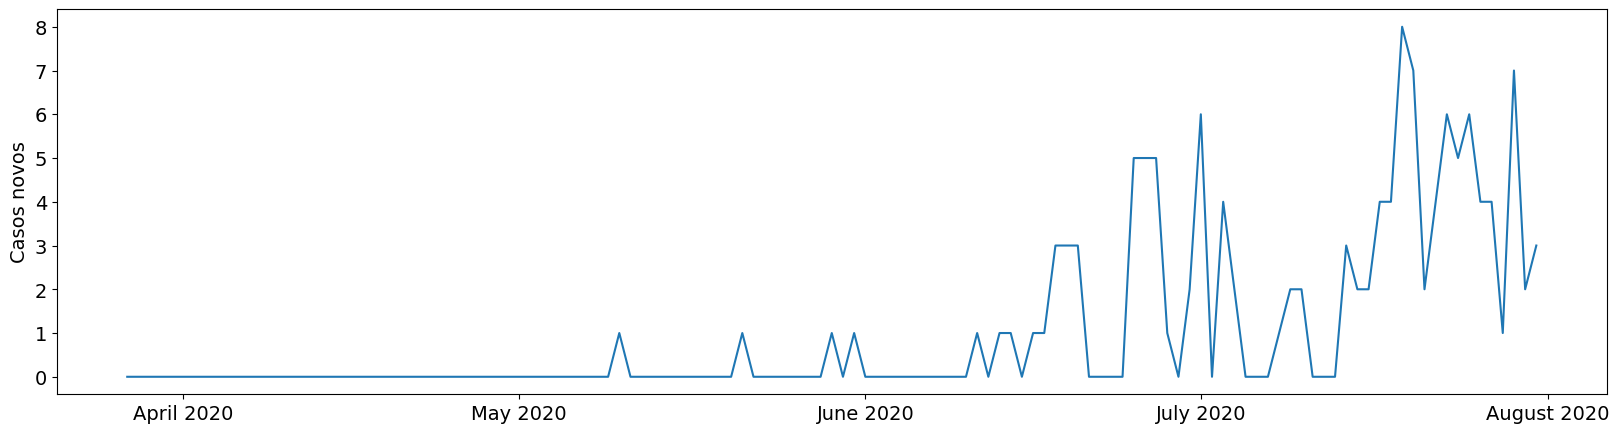

In [43]:
city_df = plot_df_sem_outliers[(plot_df_sem_outliers['municipio'] == 'Ouro Branco') & (plot_df_sem_outliers['estado'] == 'MG')]
city_df = city_df.reset_index()

smoothed_df = _suavizar(city_df)
plot_comparacao_outliers_1(smoothed_df)

C:\Users\AlterUser\AppData\Local\Temp\ipykernel_14608\2077789561.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  city_df = plot_df_sem_outliers[(df['municipio'] == 'Ouro Branco') & (df['estado'] == 'MG')]
C:\Users\AlterUser\AppData\Local\Temp\ipykernel_14608\2077789561.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ob_zscore_df = smoothed_df[abs(df["z_score"]) < LIMITE_COMUM]
C:\Users\AlterUser\AppData\Local\Temp\ipykernel_14608\3478348279.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['data'] = pd.to_datetime(df1['data'])


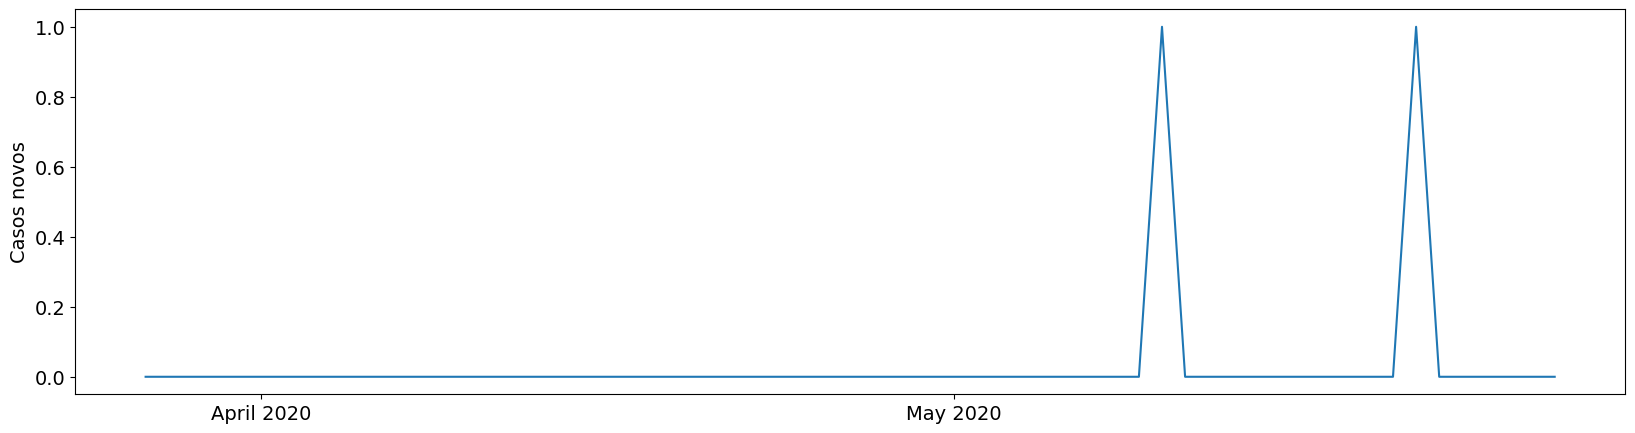

In [49]:
city_df = plot_df_sem_outliers[(df['municipio'] == 'Ouro Branco') & (df['estado'] == 'MG')]

city_df = city_df.reset_index()
smoothed_df = _suavizar(city_df)
ob_zscore_df = smoothed_df[abs(df["z_score"]) < LIMITE_COMUM]

plot_comparacao_outliers_1(ob_zscore_df)


In [16]:
df[df['casosNovos'] == -1][['municipio', 'data', 'casosNovos']]

,municipio,data,casosNovos
4527,NaN,2020-07-08,-1
4594,Alta Floresta D'Oeste,2020-05-09,-1
4609,Alta Floresta D'Oeste,2020-05-24,-1
4717,Ariquemes,2020-05-05,-1
4723,Ariquemes,2020-05-11,-1
...,...,...,...
713398,Uruana,2020-05-26,-1
713497,Urutaí,2020-04-28,-1
713685,Valparaíso de Goiás,2020-06-28,-1
714226,Vila Boa,2020-07-31,-1


In [17]:
df[df['municipio'] == 'Abadia de Goiás']['data'].max()

'2020-07-31'